# Tutorial 3 - Sediment Transport Alteration

This tutorial compares sediment transport capacity under three water-management scenarios. We will prepare grain-size and channel cross-section inputs, compute released flows and sediment transport with SARAwater, and inspect the results with `ReachPlotter`.

## Import libraries and configure paths

**NOTE**: This tutorial requires the `sarawater` package to be installed. See the [Installation guide](https://sara-acqua.github.io/sarawater/getting-started.html#installation) for details, or un-comment the cell below and run it to install the sarawater package right away.

In [1]:
# %pip install sarawater

Import the necessary libraries for the tutorial

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sarawater as sara

## Import the flow time series

This tutorial needs a CSV file with the flow discharge time series for the reach, with at least two columns: "Date" (the timestamps in a format like YYYY-MM-DD) and "Q" (the flow discharge, in cubic meters per second, m³/s).

You have two options to provide this file:

1. **Use your own data**: place your CSV file in the `data` folder next to this notebook, and update the filename in the cell below.

2. **Use the example dataset**: do nothing: if no local file is found, the notebook automatically downloads the example dataset used in this tutorial from the [SARAwater GitHub repository](https://github.com/sara-acqua/sarawater)

In [3]:
input_csv_filepath = os.path.join("data", "daily_discharge_30y.csv")

if os.path.isfile(input_csv_filepath):
    print(f"Using your local file: {input_csv_filepath}")
    reach_df = pd.read_csv(input_csv_filepath, parse_dates=["Date"])
else:
    print("No local file found - downloading the example dataset from GitHub instead.")
    GITHUB_DATA_URL = "https://raw.githubusercontent.com/sara-acqua/sarawater/main/tutorials/tutorial_1_IHA/data/daily_discharge_7y.csv"
    reach_df = pd.read_csv(GITHUB_DATA_URL, parse_dates=["Date"])

reach_df.head()

Using your local file: data\daily_discharge_30y.csv


,Date,Q
0,1989-01-01,0.142379
1,1989-01-02,0.139673
2,1989-01-03,0.136700
3,1989-01-04,0.133566
4,1989-01-05,0.130386


## Initialize the reach

In [4]:
datetime_list = reach_df["Date"].dt.to_pydatetime().tolist()
discharge_data = reach_df["Q"].to_numpy()

Qabs_max = 0.2
my_reach = sara.Reach("Sediment Tutorial Reach", datetime_list, discharge_data, Qabs_max)

## Define the grain-size distribution and cross-section geometry of the reach

The input uses cumulative fraction `i(di)` and grain diameter `di[mm]`. SARAwater converts this table into its standard 18 phi classes.

In [5]:
grain_size_data = pd.DataFrame(
    {
        "i(di)": [0.02, 0.07, 0.15, 0.30, 0.50, 0.72, 0.88, 0.97, 1.0],
         "di[mm]": [0.25, 0.5, 1, 2, 4, 8, 16, 32, 64],
    }
)

# If you want to save the grain size distribution to a CSV file, you can uncomment the line below. This will create a file named "grain_size_distribution.csv" in the "data" directory, which must be created beforehand.
# grain_size_data.to_csv(os.path.join("data", "grain_size_distribution.csv"), index=False)

grain_size_data

,i(di),di[mm]
0,0.02,0.25
1,0.07,0.50
2,0.15,1.00
3,0.30,2.00
4,0.50,4.00
5,0.72,8.00
6,0.88,16.00
7,0.97,32.00
8,1.00,64.00


The cross-section is a simple trapezoidal channel. Coordinates are transverse distance `y [m]` and bed elevation `z [m]`, as required by `Reach.add_cross_section_geometry()`.

In [6]:
cross_section_data = pd.DataFrame(
    {
        "y [m]": [0, 2, 5, 8, 10],
        "z [m]": [0.3, 0.0, 0.0, 0.0, 0.3],
    }
)

# If you want to save the cross-section data to a CSV file, you can uncomment the line below. This will create a file named "cross_section.csv" in the "data" directory, which must be created beforehand.
# cross_section_data.to_csv(os.path.join("data", "cross_section.csv"), index=False)

cross_section_data

,y [m],z [m]
0,0,0.3
1,2,0.0
2,5,0.0
3,8,0.0
4,10,0.3


Add the grain-size distribution and cross-section geometry to the reach

In [7]:
my_reach.add_grain_size_distribution(grain_size_data)
my_reach.add_cross_section_geometry(
    slope=0.05,
    ks=20,
    section=cross_section_data,
)

Loading cross-section geometry and grain-size distribution from CSV files is also possible, but not required. The code below shows how to do it, but the lines are commented out. If you want to use this option, uncomment the lines and provide the correct paths to your CSV files.

In [8]:
"""
grain_size_data_path = os.path.join("data", "grain_size_distribution.csv")
cross_section_data_path = os.path.join("data", "cross_section.csv")

my_reach.add_grain_size_distribution(grain_size_data_path)
my_reach.add_cross_section_geometry(
    slope=0.05,
    ks=20,
    section=cross_section_data_path,
)
"""

'\ngrain_size_data_path = os.path.join("data", "grain_size_distribution.csv")\ncross_section_data_path = os.path.join("data", "cross_section.csv")\n\nmy_reach.add_grain_size_distribution(grain_size_data_path)\nmy_reach.add_cross_section_geometry(\n    slope=0.05,\n    ks=20,\n    section=cross_section_data_path,\n)\n'

Note that a single width value can be used instead of a full cross-section geometry. In this case, the channel is assumed to be rectangular, and the width is used to compute the cross-sectional area and hydraulic radius. Analogously, a single grain size value can be used instead of a full grain-size distribution. In this case, the sediment is assumed to be uniform, and the single grain size is used to compute the sediment transport capacity.

Un-comment the lines below to replace the full cross-section and grain-size distribution with single values.

In [9]:
my_reach.add_cross_section_geometry(slope=0.05, ks=20, width=1.0)
my_reach.add_grain_size_distribution(0.1)

## Add three scenarios to the reach

### Minimum flow requirement scenario

In [10]:
Qreq_months = [
    0.07,
    0.07,
    0.07,
    0.085,
    0.085,
    0.085,
    0.085,
    0.08,
    0.08,
    0.085,
    0.085,
    0.07,
]
MFR_scenario = sara.ConstScenario(
    name="MFR",
    description="Monthly minimum flow requirement",
    reach=my_reach,
    Qreq_months=Qreq_months,
)
my_reach.add_scenario(MFR_scenario)
print(f"MFR range: {min(Qreq_months):.3f} to {max(Qreq_months):.3f} m³/s")

MFR range: 0.070 to 0.085 m³/s


### Ecological flow scenario

SARAwater can generate the ecological scenario from the reach's flow series using its built-in method.

In [11]:
my_reach.add_ecological_flow_scenario(
    "EF", "Ecological flow scenario with default parameters"
)
my_reach.print_scenarios()

scenarios[0]: MFR | Monthly minimum flow requirement
scenarios[1]: EF | Ecological flow scenario with default parameters


### Proportional release scenario

In [12]:
EF_scenario = my_reach.scenarios[1]
prop_scenario = sara.PropScenario(
    name="Proportional",
    description="Release requirement proportional to natural flow",
    reach=my_reach,
    Qbase=0.6 * min(Qreq_months),
    c_Qin=0.3,
    Qreq_min=min(Qreq_months),
    Qreq_max=max(EF_scenario.Qreq_months),
)
my_reach.add_scenario(prop_scenario)
my_reach.print_scenarios()

scenarios[0]: MFR | Monthly minimum flow requirement
scenarios[1]: EF | Ecological flow scenario with default parameters
scenarios[2]: Proportional | Release requirement proportional to natural flow


### Compute released flow time series `Qrel` and abstraction volumes for each scenario

In [13]:
for scenario in my_reach.scenarios:
    scenario.compute_Qrel()
    scenario.compute_natural_abstracted_volumes()

## Compute sediment transport capacity time series and annual budget

Compute the sediment-load time series and annual sediment budget for each scenario using the built-in methods `compute_sediment_load()` and `compute_annual_sediment_budget()`, respectively. By default, SARAwater uses the Wilcock-Crowe transport formula; you can compare the alternative Meyer-Peter-Müller formula by passing `transport_formula="mpm"` to `compute_sediment_load()`.

The budget is simply computed as the integral of the sediment transport capacity over time, which gives the total amount of sediment transported over the period.

In [14]:
for scenario in my_reach.scenarios:
    scenario.compute_sediment_load()
    scenario.compute_annual_sediment_budget()

### Inspect the sediment results


The `compute_sediment_load()` method creates a pandas DataFrame with the sediment transport capacity time series for each scenario, and adds it to the scenario as `sediment_load_df`. For each time step, the DataFrame contains the water depth `h`, the wetted area `Omega`, the average flow velocity `U`, the total volumetric transport rate `Qs_total`, and the transport rates by grain-size class `Qs_phi_...`.

In [15]:
for scenario in my_reach.scenarios:
    print(f"Scenario: {scenario.name}")
    display(scenario.sediment_load_df)

Scenario: MFR


,Datetime,Q,h,Omega,U,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,...,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
0,1989-01-01,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
1,1989-01-02,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
2,1989-01-03,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
3,1989-01-04,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
4,1989-01-05,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10952,2018-12-27,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
10953,2018-12-28,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
10954,2018-12-29,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333
10955,2018-12-30,0.07,0.082556,0.082556,0.847907,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006333,0.0,0.0,0.0,0.0,0.006333


Scenario: EF


,Datetime,Q,h,Omega,U,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,...,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
0,1989-01-01,0.103283,0.104258,0.104258,0.990650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009095,0.0,0.0,0.0,0.0,0.009095
1,1989-01-02,0.103283,0.104258,0.104258,0.990650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009095,0.0,0.0,0.0,0.0,0.009095
2,1989-01-03,0.103283,0.104258,0.104258,0.990650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009095,0.0,0.0,0.0,0.0,0.009095
3,1989-01-04,0.103283,0.104258,0.104258,0.990650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009095,0.0,0.0,0.0,0.0,0.009095
4,1989-01-05,0.103283,0.104258,0.104258,0.990650,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009095,0.0,0.0,0.0,0.0,0.009095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10952,2018-12-27,0.112551,0.109774,0.109774,1.025295,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009851,0.0,0.0,0.0,0.0,0.009851
10953,2018-12-28,0.112551,0.109774,0.109774,1.025295,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009851,0.0,0.0,0.0,0.0,0.009851
10954,2018-12-29,0.112551,0.109774,0.109774,1.025295,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009851,0.0,0.0,0.0,0.0,0.009851
10955,2018-12-30,0.112551,0.109774,0.109774,1.025295,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.009851,0.0,0.0,0.0,0.0,0.009851


Scenario: Proportional


,Datetime,Q,h,Omega,U,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,...,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
0,1989-01-01,0.084714,0.092569,0.092569,0.915146,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007565,0.0,0.0,0.0,0.0,0.007565
1,1989-01-02,0.083902,0.092035,0.092035,0.911628,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007497,0.0,0.0,0.0,0.0,0.007497
2,1989-01-03,0.083010,0.091447,0.091447,0.907739,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007423,0.0,0.0,0.0,0.0,0.007423
3,1989-01-04,0.082070,0.090824,0.090824,0.903613,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007345,0.0,0.0,0.0,0.0,0.007345
4,1989-01-05,0.081116,0.090189,0.090189,0.899397,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007265,0.0,0.0,0.0,0.0,0.007265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10952,2018-12-27,0.081119,0.090191,0.090191,0.899410,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007265,0.0,0.0,0.0,0.0,0.007265
10953,2018-12-28,0.080969,0.090091,0.090091,0.898744,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007253,0.0,0.0,0.0,0.0,0.007253
10954,2018-12-29,0.080727,0.089930,0.089930,0.897670,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007233,0.0,0.0,0.0,0.0,0.007233
10955,2018-12-30,0.080417,0.089722,0.089722,0.896289,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.007207,0.0,0.0,0.0,0.0,0.007207


The `compute_annual_sediment_budget()` method returns a pandas DataFrame with the annual sediment budget for each scenario and grain size class, and adds it to the scenario as `annual_sediment_budget`.

In [16]:
for scenario in my_reach.scenarios:
    print(f"Scenario: {scenario.name}")
    display(scenario.annual_sediment_budget)

Scenario: MFR


,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,Qs_phi_-4.5,Qs_phi_-3.5,Qs_phi_-2.5,Qs_phi_-1.5,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
Year,,,,,,,,,,,,,,,,,,,
1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,460940.272983,0.0,0.0,0.0,0.0,460940.272983
1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,310120.408251,0.0,0.0,0.0,0.0,310120.408251
1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,409968.085376,0.0,0.0,0.0,0.0,409968.085376
1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,792019.859685,0.0,0.0,0.0,0.0,792019.859685
1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,498093.760305,0.0,0.0,0.0,0.0,498093.760305
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,704808.504934,0.0,0.0,0.0,0.0,704808.504934
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,397860.492299,0.0,0.0,0.0,0.0,397860.492299
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,522839.952475,0.0,0.0,0.0,0.0,522839.952475
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,356407.838904,0.0,0.0,0.0,0.0,356407.838904


Scenario: EF


,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,Qs_phi_-4.5,Qs_phi_-3.5,Qs_phi_-2.5,Qs_phi_-1.5,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
Year,,,,,,,,,,,,,,,,,,,
1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,524955.467741,0.0,0.0,0.0,0.0,524955.467741
1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370781.895990,0.0,0.0,0.0,0.0,370781.895990
1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,469648.284684,0.0,0.0,0.0,0.0,469648.284684
1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,850517.241528,0.0,0.0,0.0,0.0,850517.241528
1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,563617.914079,0.0,0.0,0.0,0.0,563617.914079
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,771411.736631,0.0,0.0,0.0,0.0,771411.736631
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,449463.192269,0.0,0.0,0.0,0.0,449463.192269
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,577678.379793,0.0,0.0,0.0,0.0,577678.379793
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,399140.859052,0.0,0.0,0.0,0.0,399140.859052


Scenario: Proportional


,Qs_phi_-9.5,Qs_phi_-8.5,Qs_phi_-7.5,Qs_phi_-6.5,Qs_phi_-5.5,Qs_phi_-4.5,Qs_phi_-3.5,Qs_phi_-2.5,Qs_phi_-1.5,Qs_phi_-0.5,Qs_phi_0.5,Qs_phi_1.5,Qs_phi_2.5,Qs_phi_3.5,Qs_phi_4.5,Qs_phi_5.5,Qs_phi_6.5,Qs_phi_7.5,Qs_total
Year,,,,,,,,,,,,,,,,,,,
1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,488597.341585,0.0,0.0,0.0,0.0,488597.341585
1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324123.234082,0.0,0.0,0.0,0.0,324123.234082
1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,437141.800559,0.0,0.0,0.0,0.0,437141.800559
1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,813268.112873,0.0,0.0,0.0,0.0,813268.112873
1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,529592.509695,0.0,0.0,0.0,0.0,529592.509695
1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,740645.772458,0.0,0.0,0.0,0.0,740645.772458
1995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,416183.391047,0.0,0.0,0.0,0.0,416183.391047
1996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,557166.730560,0.0,0.0,0.0,0.0,557166.730560
1997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,375471.644246,0.0,0.0,0.0,0.0,375471.644246


## Plot the results

In [17]:
plt.rcParams.update(
    {
        "figure.figsize": (8, 6),
        "font.size": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2,
    }
)
scenario_colors = ["tab:red", "tab:orange", "tab:green"]
plotter = sara.ReachPlotter(
    my_reach,
    scenario_colors=scenario_colors,
)

<Axes: title={'center': 'Sediment Tutorial Reach - Discharge Comparison'}, xlabel='Date', ylabel='Discharge (m³/s)'>

<Figure size 800x600 with 0 Axes>

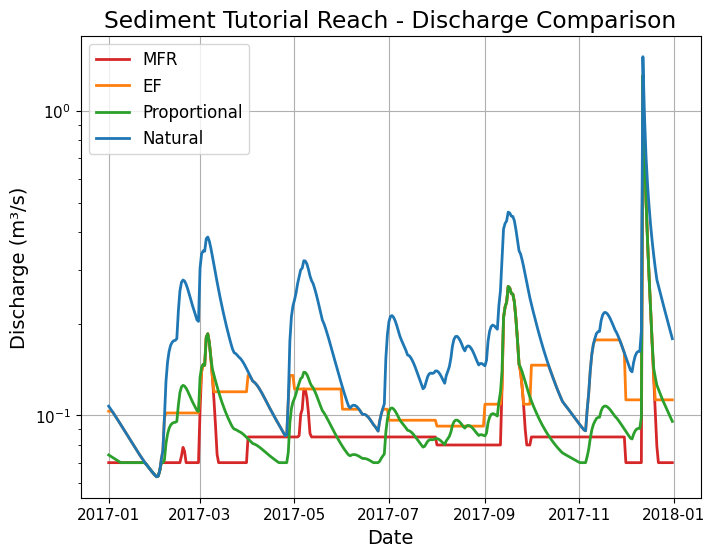

In [18]:
plt.figure()
year = 2017
start_date = f"{year}-01-01"
end_date = f"{year}-12-31"
plotter.plot_scenarios_discharge(start_date=start_date, end_date=end_date)

The total-load plot compares scenarios. The class-resolved plot uses one time-by-size heatmap per scenario with a shared transport scale. The annual budget plot shows annual volumes by grain-size class. The final comparison relates each scenario's annual sediment budget to the natural budget for matching years.

<Axes: title={'center': 'Sediment Tutorial Reach - Total Sediment Load'}, xlabel='Date', ylabel='Total Sediment Load (m³/s)'>

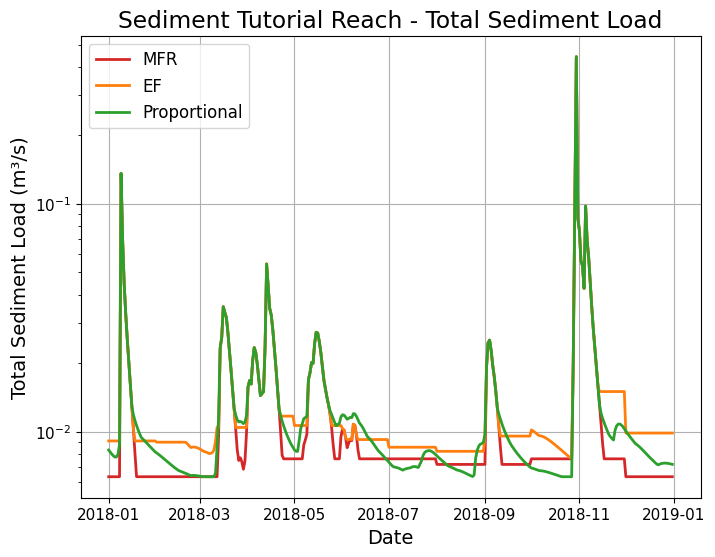

In [19]:
start_date = "2018-01-01"
end_date = "2018-12-31"
plotter.plot_sediment_load_total(
    start_date=start_date,
    end_date=end_date,
    log_scale=True,
    save=True,
)

Saved figures: `outputs/sediment_load_total.png`, `outputs/sediment_load_by_class.png`, `outputs/annual_sediment_budget_by_class.png`, and `outputs/sediment_budget_vs_volume.png`.

<Axes: title={'center': 'Sediment Tutorial Reach - Sediment Budget vs Abstracted Volume'}, xlabel='Normalized sediment budget (scenario / natural) [-]', ylabel='Normalized abstracted volume $V_{der}/V_{nat}$ [-]'>

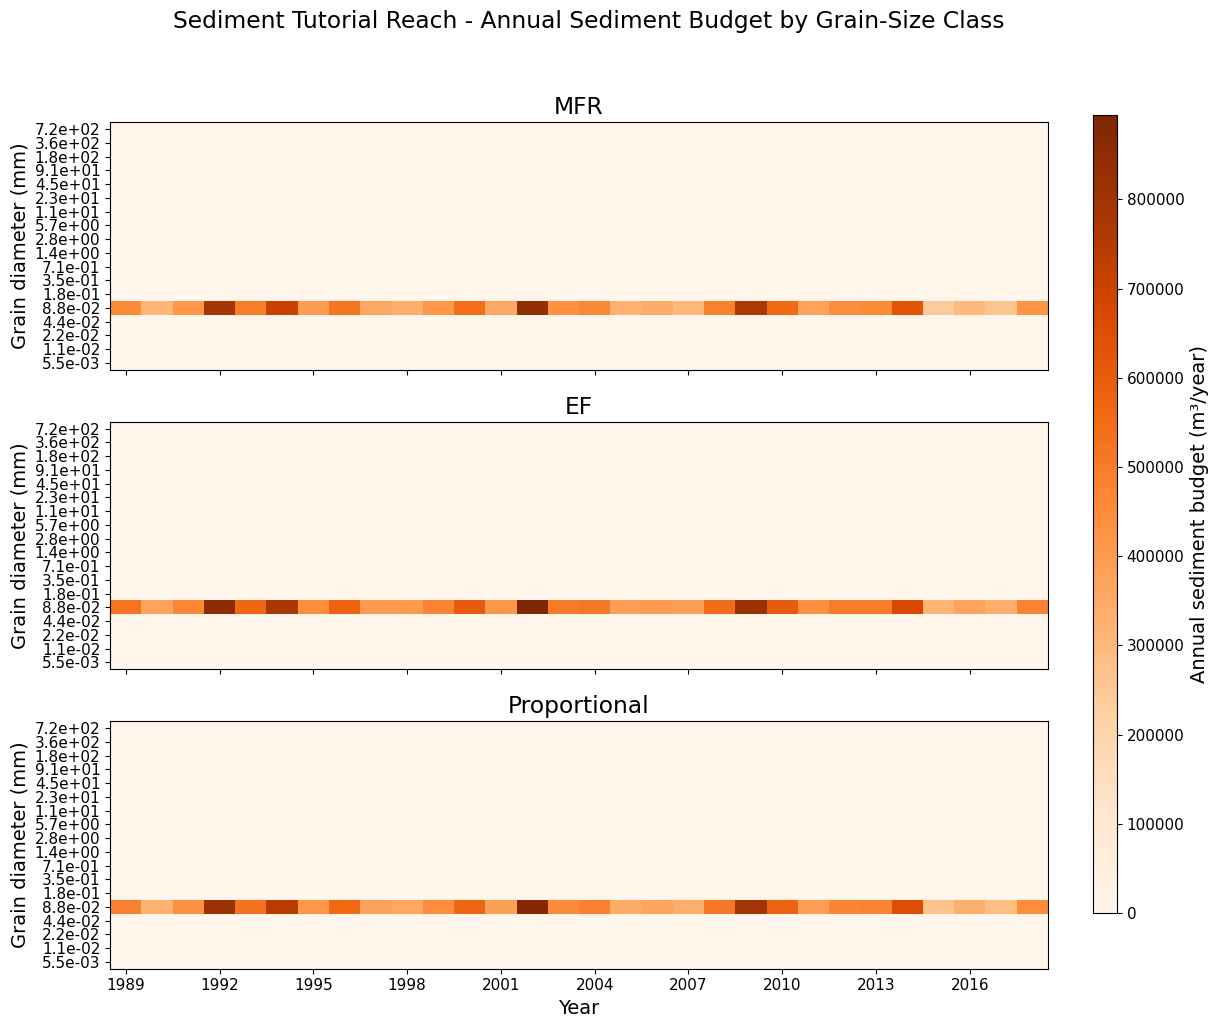

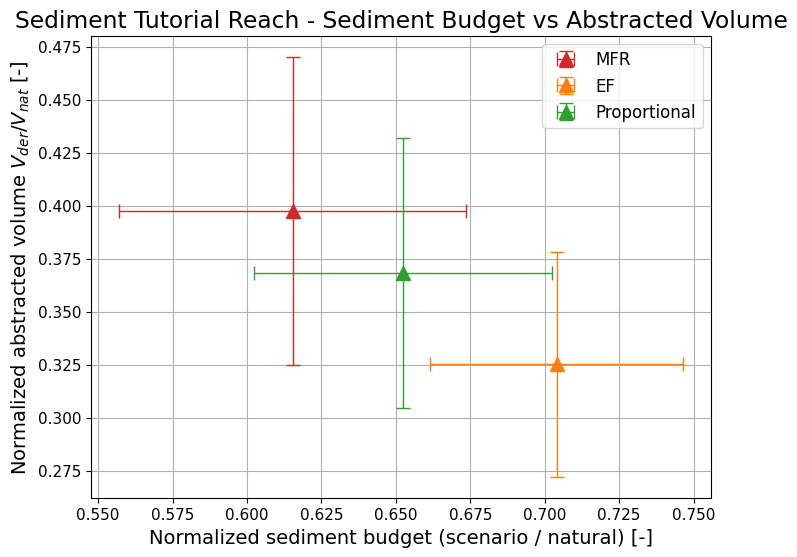

In [20]:
plotter.plot_annual_sediment_budget_by_class(
    save=True,
)

# Compute the reference budget explicitly; the comparison plot also does this if needed.
my_reach.compute_natural_sediment_budget()
plotter.plot_sediment_budget_vs_volume(save=True)